# Single-Cross (Jane Street, February 2020)

A line segment of length $D$ is dropped uniformly at random (random position, random orientation) onto a plane ruled with a unit square grid.
Which $D$ maximizes the probability that the segment crosses **exactly one** grid line, and what is that probability?

Equivalently: pick the first endpoint uniformly in a unit square and the second endpoint at distance exactly $D$ in a uniformly random direction.
The segment crosses exactly one line iff the second endpoint lands in one of the 4 edge-adjacent squares.

In [1]:
import time

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize_scalar

## Monte Carlo simulation

The number of vertical lines crossed is $|\lfloor x_2 \rfloor - \lfloor x_1 \rfloor|$ (and likewise for horizontal lines), so we can count crossings directly for any $D$.

In [2]:
def simulate(d, n, rng):
    x1 = rng.uniform(0, 1, n)
    y1 = rng.uniform(0, 1, n)
    angle = rng.uniform(0, 2 * np.pi, n)
    x2 = x1 + d * np.cos(angle)
    y2 = y1 + d * np.sin(angle)
    crossings = np.abs(np.floor(x2) - np.floor(x1)) + np.abs(np.floor(y2) - np.floor(y1))
    return np.mean(crossings == 1)


start = time.time()
rng = np.random.default_rng(2020)
n = 1_000_000
d_list = np.arange(0.01, np.sqrt(5), 0.01)
probability = np.array([simulate(d, n, rng) for d in d_list])
end = time.time()

In [3]:
print(f"time: {end - start:.1f} s")
best = probability.argmax()
print(f"best D = {d_list[best]:.2f}, probability = {probability[best]:.5f}")

time: 17.1 s
best D = 0.99, probability = 0.63700


The curve is very flat near its peak ($P(1) - P(0.99) \approx 6 \times 10^{-5}$), well below the sampling error of about $5 \times 10^{-4}$ at $n = 10^6$, so the simulated argmax landing on $0.99$ instead of $1$ is just noise.

## Exact probability

By symmetry take the angle $\theta \in [0, \pi/2]$ uniform, and let $a = D\cos\theta$, $b = D\sin\theta$ be the segment's horizontal and vertical extents.
Given $\theta$, the horizontal and vertical offsets of the segment are independent and uniform, so the number of vertical lines crossed is
$\lfloor a \rfloor + 1$ with probability $a - \lfloor a \rfloor$ and $\lfloor a \rfloor$ otherwise (likewise for $b$). Hence

$$P(D) = \frac{2}{\pi}\int_0^{\pi/2} \Big[ p_1(a)\,p_0(b) + p_0(a)\,p_1(b) \Big]\, d\theta,$$

where $p_k(a)$ is the probability of crossing exactly $k$ lines with extent $a$.

For $D \le 1$ we have $p_1(a) = a$ and $p_0(a) = 1 - a$, so

$$P(D) = \frac{2}{\pi}\int_0^{\pi/2} \big[ D\cos\theta + D\sin\theta - 2D^2\sin\theta\cos\theta \big]\, d\theta = \frac{4D - 2D^2}{\pi},$$

which increases on $[0, 1]$ and reaches $2/\pi$ at $D = 1$.

Just past $D = 1$, near $\theta = 0$ the horizontal extent $a$ exceeds $1$ and the segment can cross two vertical lines: the integrand there becomes $(2-a)(1-b)$, which is smaller than $a(1-b) + (1-a)b$ by $(a-1)(2-3b) > 0$ on an angular window of width about $\sqrt{2(D-1)}$ (and symmetrically near $\theta = \pi/2$).
So $P(1+\varepsilon) = 2/\pi - O(\varepsilon^{3/2})$, and $D = 1$ is a maximum with zero slope on both sides.
For $D \ge \sqrt{5}$ the segment always crosses at least two lines, so $P(D) = 0$. The integral for $1 < D < \sqrt{5}$ is evaluated numerically below.

In [4]:
def p_cross(extent, k):
    whole = np.floor(extent)
    if k == whole + 1:
        return extent - whole
    if k == whole:
        return whole + 1 - extent
    return 0.0


def integrand(theta, d):
    a = d * np.cos(theta)
    b = d * np.sin(theta)
    return p_cross(a, 1) * p_cross(b, 0) + p_cross(a, 0) * p_cross(b, 1)


def exact_probability(d):
    # angles where a or b passes an integer, so quad can split the integral there
    kinks = [np.arccos(k / d) for k in (1, 2) if k < d] + [np.arcsin(k / d) for k in (1, 2) if k < d]
    return 2 / np.pi * quad(integrand, 0, np.pi / 2, args=(d,), points=kinks or None, limit=200)[0]


exact = np.array([exact_probability(d) for d in d_list])
print("max |simulation - exact| =", np.abs(probability - exact).max())
print("max |exact - (4D - 2D^2)/pi| for D <= 1 =",
      np.abs(exact - (4 * d_list - 2 * d_list**2) / np.pi)[d_list <= 1].max())
print("exact P(D) strictly decreasing for 1 < D < sqrt(5):", bool(np.all(np.diff(exact[d_list >= 1]) < 0)))

max |simulation - exact| = 0.0011673047306933748
max |exact - (4D - 2D^2)/pi| for D <= 1 = 1.1102230246251565e-16
exact P(D) strictly decreasing for 1 < D < sqrt(5): True


In [5]:
result = minimize_scalar(lambda d: -exact_probability(d), bounds=(0.5, 1.5), method="bounded",
                         options={"xatol": 1e-10})
print(f"D = {result.x:.8f}, probability = {-result.fun:.10f}, 2/pi = {2 / np.pi:.10f}")

D = 1.00000000, probability = 0.6366197724, 2/pi = 0.6366197724


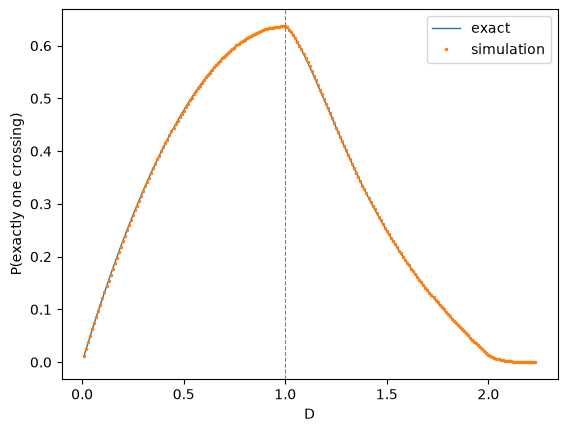

In [6]:
plt.plot(d_list, exact, linewidth=1, label="exact")
plt.plot(d_list, probability, ".", markersize=3, label="simulation")
plt.axvline(1, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("D")
plt.ylabel("P(exactly one crossing)")
plt.legend()
plt.show()

# Answer

$D = 1$, and the maximal probability is $\dfrac{2}{\pi} \approx 0.6366198$.

*Note:* an earlier version of this notebook reported $D \approx 1.22307$ with probability $\approx 0.45396$. That was mainly because it drew the segment length uniformly from $[0, D]$ instead of fixing it at $D$ (it also passed integer degrees to `np.cos`/`np.sin` as radians, which matters little), and the reported maximum was further inflated by taking the largest of many noisy estimates.